In [57]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
# For feature Engineering 
from sklearn.preprocessing import LabelEncoder,StandardScaler
# For splitting data into X and y (Train & Test)
from sklearn.model_selection import train_test_split
# Models to train
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = sns.load_dataset('iris')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [7]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [8]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

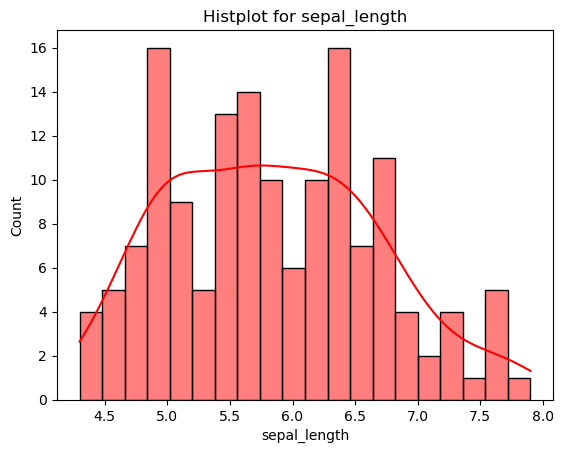

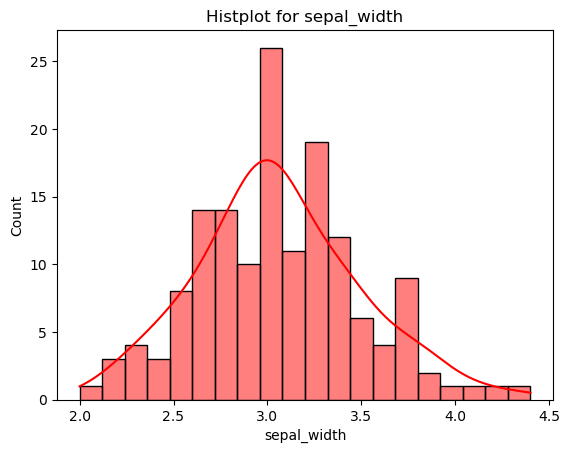

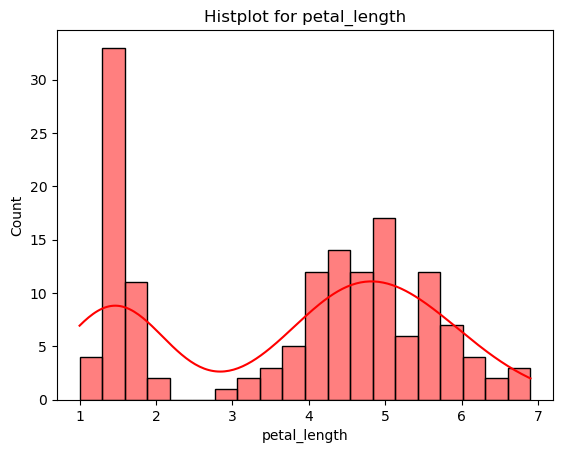

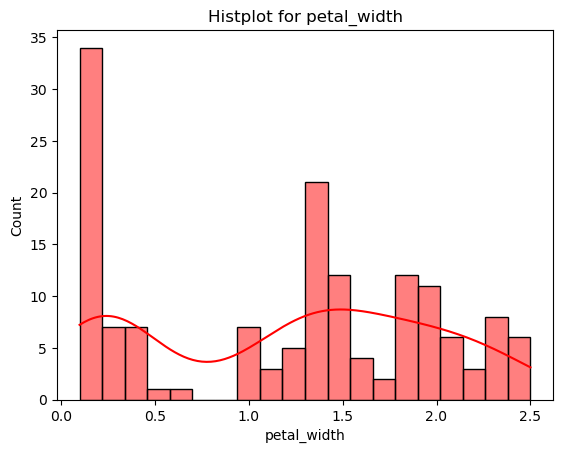

In [9]:
def histogram(df,col): 
    plt.title(f"Histplot for {col}")
    sns.histplot(df,x=col,color='red',kde=True,bins=20)
    plt.show()
num_cols = ['sepal_length','sepal_width','petal_length','petal_width']
for x in num_cols:
    histogram(df,x)

In [10]:
print(df['species'].unique()) 
print(df.head())

['setosa' 'versicolor' 'virginica']
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


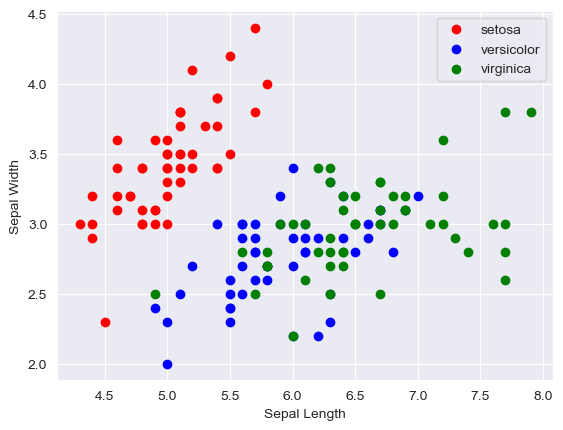

In [11]:
color = ['red','blue','green']
species = ['setosa','versicolor','virginica']

for i in range(3):
    x = df[df['species'] == species[i]]
    sns.set_style('darkgrid')
    plt.scatter(x['sepal_length'],x['sepal_width'],c=color[i],label=species[i])

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.show()

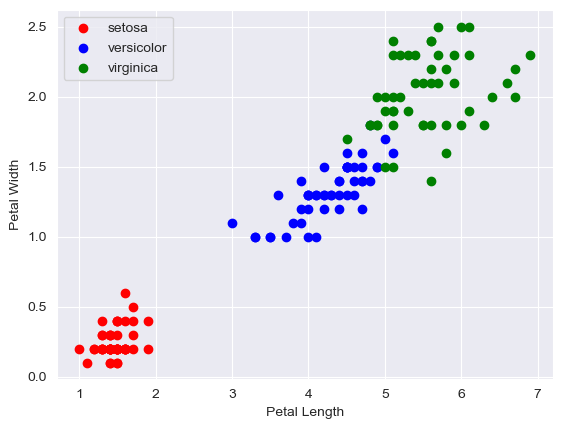

In [12]:
color = ['red','blue','green']
species = ['setosa','versicolor','virginica']

for i in range(3):
    x = df[df['species'] == species[i]]
    sns.set_style('darkgrid')
    plt.scatter(x['petal_length'],x['petal_width'],c=color[i],label=species[i])

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.show()

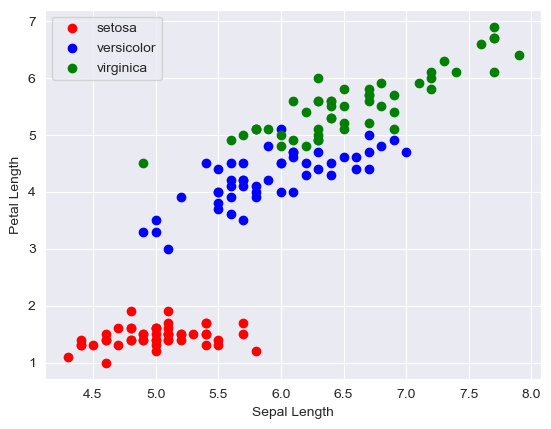

In [13]:
color = ['red','blue','green']
species = ['setosa','versicolor','virginica']

for i in range(3):
    x = df[df['species'] == species[i]]
    sns.set_style('darkgrid')
    plt.scatter(x['sepal_length'],x['petal_length'],c=color[i],label=species[i])

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.legend()
plt.show()

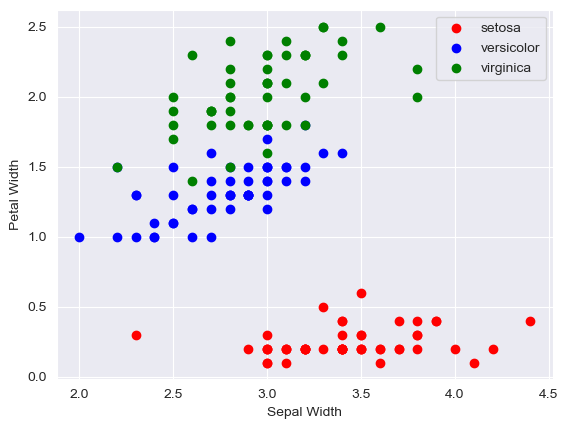

In [14]:
color = ['red','blue','green']
species = ['setosa','versicolor','virginica']

for i in range(3):
    x = df[df['species'] == species[i]]
    sns.set_style('darkgrid')
    plt.scatter(x['sepal_width'],x['petal_width'],c=color[i],label=species[i])

plt.xlabel("Sepal Width")
plt.ylabel("Petal Width")
plt.legend()
plt.show()

<Axes: title={'center': 'Heatmap of numerical Values'}>

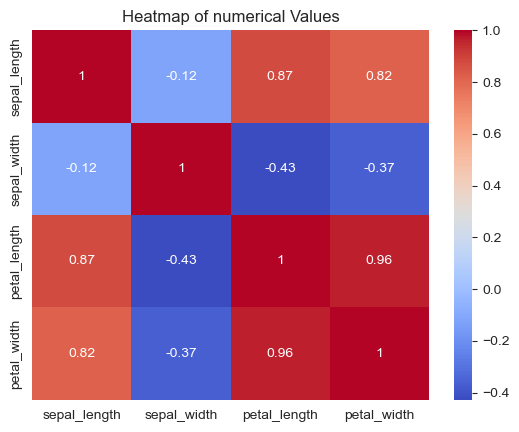

In [15]:
plt.title("Heatmap of numerical Values")
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')

In [22]:
lb = LabelEncoder()

df['species'] = lb.fit_transform(df['species'])
print(df['species'].unique())
print("\n",df.head())

[0 1 2]

    sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0


## Model Training

### Train test Split

In [25]:
X = df.drop(columns=['species'])
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=12, test_size=0.3)

### Feature Engineering and Scaling  

In [46]:
# For X_train 
X_train['Petal_area'] = X_train['petal_length'] * X_train['petal_width']

# For X_test 
X_test['Petal_area'] = X_test['petal_length'] * X_test['petal_width']
print("X Train after feature Engineering:")
X_train.head()

X Train after feature Engineering:


,sepal_length,sepal_width,petal_length,petal_width,Petal_area
10,5.4,3.7,1.5,0.2,0.30
46,5.1,3.8,1.6,0.2,0.32
36,5.5,3.5,1.3,0.2,0.26
124,6.7,3.3,5.7,2.1,11.97
7,5.0,3.4,1.5,0.2,0.30


### Feature Scaling 

In [51]:
scalar = StandardScaler()

X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

feature_names = list(X_train.columns)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

print("X train Head after Scaling")
X_train_scaled.head()

X train Head after Scaling


,sepal_length,sepal_width,petal_length,petal_width,Petal_area
10,-0.617867,1.628637,-1.426426,-1.413620,-1.270828
46,-0.977623,1.875756,-1.368441,-1.413620,-1.266594
36,-0.497948,1.134397,-1.542396,-1.413620,-1.279296
124,0.941076,0.640158,1.008936,1.086533,1.199678
7,-1.097541,0.887277,-1.426426,-1.413620,-1.270828


### Pick a model to train

In [52]:
model = LogisticRegression()

model.fit(X_train_scaled,y_train)

LogisticRegression()

In [60]:
y_pred = model.predict(X_test_scaled)

accuracy_score(y_pred,y_test)*100

97.77777777777777

In [61]:
#2 training and testing
model_2 = KNeighborsClassifier()

model_2.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [64]:
y_pred_2 = model_2.predict(X_test_scaled)

accuracy_score(y_pred_2,y_test)*100

97.77777777777777